<a href="https://colab.research.google.com/github/dikshit-neupane/Share-Price-prediction/blob/ml-dev/cleaning_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Cleaning


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("/content/nepse_full_market.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)
print("Shape:", df.shape)
print("Dtypes:\n", df.dtypes)
print(df.head())

#converts date to datetime object groups symbols by the dates

Shape: (342791, 9)
Dtypes:
 date          datetime64[ns]
open                 float64
high                 float64
low                  float64
close                float64
pct_change           float64
volume               float64
turnover             float64
symbol                object
dtype: object
        date    open    high     low   close  pct_change  volume   turnover  \
0 2021-01-10   752.0   811.0   752.0   811.0        9.89   635.0   513385.0   
1 2021-01-11   827.0   892.0   827.0   892.0        9.99   380.0   336520.0   
2 2021-01-12   909.0   981.0   909.0   981.0        9.98   406.0   396486.0   
3 2021-01-13  1030.0  1079.0  1030.0  1079.0        9.99  6886.0  7424348.0   
4 2021-01-17  1132.0  1186.0  1132.0  1186.0        9.92  3217.0  3805112.0   

   symbol  
0  ACLBSL  
1  ACLBSL  
2  ACLBSL  
3  ACLBSL  
4  ACLBSL  


In [18]:
dupes = df.duplicated(subset=['symbol', 'date']).sum()
print("Duplicate (symbol, date) rows found:", dupes)
#checks duplicates id same stock are traded in same date have 2 or more entries

Duplicate (symbol, date) rows found: 0


In [19]:
df = df.drop_duplicates(subset=['symbol', 'date'], keep='first').reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)
#delets rows if any such found but in our case we didn't find any

Shape after dropping duplicates: (342791, 9)


In [20]:
invalid_prices = df[(df['open'] <= 0) | (df['high'] <= 0) | (df['low'] <= 0) | (df['close'] <= 0)]
print("Rows with non-positive prices:", len(invalid_prices))
print("Negative volume rows:", (df['volume'] < 0).sum())
print("Negative turnover rows:", (df['turnover'] < 0).sum())
#checks if any negative prices are found

Rows with non-positive prices: 0
Negative volume rows: 0
Negative turnover rows: 0


In [22]:
bad_ohlc = df[
    (df['low'] > df['open']) | (df['low'] > df['close']) |
    (df['low'] > df['high']) | (df['high'] < df['open']) |
    (df['high'] < df['close'])
]
print("OHLC inconsistent rows:", len(bad_ohlc))
#check inconsistencies in open , close , high , low a common inconsistency in Stock data

OHLC inconsistent rows: 909


In [24]:
ohlc_cols = ['open', 'high', 'low', 'close']
df['high'] = df[ohlc_cols].max(axis=1)
df['low']  = df[ohlc_cols].min(axis=1)
print("Shape after OHLC fix:", df.shape)
#not dropping incocnsistency as its too small in size only 909 rows are inconsistent keeping the highest in high column and lowest in low column

Shape after OHLC fix: (342791, 9)


In [8]:
bad_ohlc = df[
    (df['low'] > df['open']) | (df['low'] > df['close']) |
    (df['low'] > df['high']) | (df['high'] < df['open']) |
    (df['high'] < df['close'])
]
print("OHLC inconsistent rows:", len(bad_ohlc))
#checking again after fix

OHLC inconsistent rows: 0


In [25]:
counts = df.groupby('symbol').size()
print("Symbol count distribution:\n", counts.describe())
valid_symbols = counts[counts >= 100].index
df = df[df['symbol'].isin(valid_symbols)].reset_index(drop=True)
print("Symbols remaining:", df['symbol'].nunique())
print("Rows remaining:", df.shape[0])
#keeps the symbol with 50 trading Days

Symbol count distribution:
 count     544.000000
mean      630.130515
std       480.586658
min         1.000000
25%       136.000000
50%       605.000000
75%      1210.750000
max      1262.000000
dtype: float64
Symbols remaining: 430
Rows remaining: 339595


In [27]:
counts = df.groupby('symbol').size()
print("Symbols with >1000 rows:", (counts > 1000).sum())
valid_symbols = counts[counts > 1000].index
df = df[df['symbol'].isin(valid_symbols)].reset_index(drop=True)
print("Symbols remaining:", df['symbol'].nunique())
print("Rows remaining:", df.shape[0])
print(df.groupby('symbol').size().sort_values(ascending=False))
#narrow down keep only symbol with more than 1000 trading days history

Symbols with >1000 rows: 172
Symbols remaining: 172
Rows remaining: 211803
symbol
ADBL     1262
AHPC     1262
AKJCL    1262
AKPL     1262
BFC      1262
         ... 
NYADI    1045
SPC      1042
MBJC     1027
HBL      1012
BNHC     1010
Length: 172, dtype: int64


In [32]:
df['date_diff'] = df.groupby('symbol')['date'].diff().dt.days
gap_summary = df[df['date_diff'] > 30].groupby('symbol').size().sort_values(ascending=False)
print("Symbols with gaps >30 days:", len(gap_summary))
print(gap_summary.head(20))
#checks the gap betwwen consecutive traing days and picks symbols with gap more than 30 days

Symbols with gaps >30 days: 11
symbol
GBIME     2
SKBBL     2
NMFBS     2
GBLBS     1
BBC       1
KBL       1
HBL       1
PRIN      1
RBCL      1
RBCLPO    1
SLBSL     1
dtype: int64


In [33]:
df = df.drop(columns=['date_diff'])
#drops columns date_diff

In [38]:
df['pct_change_calc'] = df.groupby('symbol')['close'].pct_change() * 100
df['pct_diff'] = (df['pct_change'] - df['pct_change_calc']).abs()

mismatches = df[df['pct_diff'] > 5]
print("Rows with large pct_change mismatch (>5%):", len(mismatches))
print(mismatches[['symbol','date','close','pct_change','pct_change_calc']].head(10))

df['split_flag'] = (df['pct_diff'] > 5).astype(int)
print("Total flagged rows:", df['split_flag'].sum())

df = df.drop(columns=['pct_change_calc', 'pct_diff'])
#checks price chance of yesterdays close and todays close as nepse isues bonus shares right shares and prices get halved

Rows with large pct_change mismatch (>5%): 381
      symbol       date   close  pct_change  pct_change_calc
54    ACLBSL 2021-03-31  1576.0        2.94        -5.458908
293   ACLBSL 2022-03-31  1101.1       -0.62       -17.582335
1493    ADBL 2022-01-02   411.0        0.24       -16.463415
2569    AHPC 2021-03-22   260.0        7.44       -16.932907
2695    AHPC 2021-09-27   492.0       -5.93       -14.434783
3016    AHPC 2023-02-01   302.0       -2.05        -9.309309
3243    AHPC 2024-01-29   209.1        9.99       -25.374732
4615   AKJCL 2024-07-16   162.8       10.00       -26.000000
5201    AKPL 2021-08-31   659.0       -3.23       -17.314931
5485    AKPL 2022-11-06   378.0        4.21        -5.263158
Total flagged rows: 381


In [39]:
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)
print("Final cleaned shape:", df.shape)
print(df.dtypes)
print(df.head())
df.to_csv('nepse_cleaned.csv', index=False)
print("Saved to nepse_cleaned.csv")

Final cleaned shape: (211803, 10)
date          datetime64[ns]
open                 float64
high                 float64
low                  float64
close                float64
pct_change           float64
volume               float64
turnover             float64
symbol                object
split_flag             int64
dtype: object
        date    open    high     low   close  pct_change  volume   turnover  \
0 2021-01-10   752.0   811.0   752.0   811.0        9.89   635.0   513385.0   
1 2021-01-11   827.0   892.0   827.0   892.0        9.99   380.0   336520.0   
2 2021-01-12   909.0   981.0   909.0   981.0        9.98   406.0   396486.0   
3 2021-01-13  1030.0  1079.0  1030.0  1079.0        9.99  6886.0  7424348.0   
4 2021-01-17  1132.0  1186.0  1132.0  1186.0        9.92  3217.0  3805112.0   

   symbol  split_flag  
0  ACLBSL           0  
1  ACLBSL           0  
2  ACLBSL           0  
3  ACLBSL           0  
4  ACLBSL           0  
Saved to nepse_cleaned.csv


# Eda start

In [42]:
print(df.describe())
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Number of symbols:", df['symbol'].nunique())
print("Avg rows per symbol:", round(df.groupby('symbol').size().mean(), 1))
#checks min max mean of all columns

                                date           open           high  \
count                         211803  211803.000000  211803.000000   
mean   2023-09-17 19:21:50.921941504    1079.247653    1096.686125   
min              2021-01-03 00:00:00       6.710000       6.890000   
25%              2022-05-25 00:00:00     275.000000     280.000000   
50%              2023-09-05 00:00:00     472.000000     482.000000   
75%              2025-01-20 00:00:00     846.000000     860.000000   
max              2026-06-05 00:00:00   55080.000000   56805.800000   
std                              NaN    3174.136710    3207.238314   

                 low          close     pct_change        volume  \
count  211803.000000  211803.000000  211803.000000  2.118030e+05   
mean     1061.442076    1077.652502       0.089538  5.594910e+04   
min         6.530000       6.780000     -14.990000  1.000000e+00   
25%       268.100000     274.000000      -1.350000  5.137000e+03   
50%       461.000000     470.

In [41]:
date_ranges = df.groupby('symbol')['date'].agg(['min', 'max', 'count'])
print(date_ranges.describe())
print("\nSymbols with shortest history:")
print(date_ranges.sort_values('count').head(10))
#can find is all symbols covers same date range

                                 min                            max  \
count                            172                            172   
mean   2021-02-03 05:01:23.720930304  2026-06-04 23:51:37.674418688   
min              2021-01-03 00:00:00            2026-06-04 00:00:00   
25%              2021-01-03 00:00:00            2026-06-05 00:00:00   
50%              2021-01-03 00:00:00            2026-06-05 00:00:00   
75%              2021-01-03 00:00:00            2026-06-05 00:00:00   
max              2022-01-18 00:00:00            2026-06-05 00:00:00   
std                              NaN                            NaN   

             count  
count   172.000000  
mean   1231.412791  
min    1010.000000  
25%    1232.750000  
50%    1261.000000  
75%    1262.000000  
max    1262.000000  
std      60.052886  

Symbols with shortest history:
              min        max  count
symbol                             
BNHC   2022-01-18 2026-06-05   1010
HBL    2021-01-03 2026-06-05   

In [43]:
activity = df.groupby('symbol').agg(
    avg_volume=('volume', 'mean'),
    avg_turnover=('turnover', 'mean'),
    avg_close=('close', 'mean'),
    days=('date', 'count')
).sort_values('avg_turnover', ascending=False)

print("Top 10 most active symbols by turnover:")
print(activity.head(10))

print("\nBottom 10 least active symbols by turnover:")
print(activity.tail(10))
#sorting most active and least active symbols by turnover


Top 10 most active symbols by turnover:
           avg_volume  avg_turnover    avg_close  days
symbol                                                
NRIC     88049.774168  1.103642e+08  1033.694873  1262
SHIVM   149695.351823  1.011336e+08   789.917662  1262
NGPL    231478.282092  9.463943e+07   388.566490  1262
HDL      39494.493661  8.626460e+07  2702.963019  1262
API     253972.339144  8.536645e+07   294.041157  1262
NRN      76351.901743  8.530053e+07   875.082575  1262
AHPC    216474.237718  7.851644e+07   313.482163  1262
RADHI   116310.657143  7.331051e+07   492.378103  1260
NIFRA   212410.982157  7.183381e+07   285.526910  1233
NABIL    77815.202060  6.556045e+07   762.220927  1262

Bottom 10 least active symbols by turnover:
          avg_volume   avg_turnover  avg_close  days
symbol                                              
LUK     47495.921837  523048.474730   9.430983  1241
NBF3    49700.458453  449011.286371   8.513372  1047
SBCF    40022.285714  381606.313301   8.662

In [46]:
volatility = df.groupby('symbol')['pct_change'].std().sort_values(ascending=False)
print("Top 10 most volatile symbols:")
print(volatility.head(10))
print("\nBottom 10 least volatile symbols:")
print(volatility.tail(10))
#most volatile and least volatile

Top 10 most volatile symbols:
symbol
CORBL     3.868195
SAPDBL    3.647374
NFS       3.585288
GRDBL     3.522523
JOSHI     3.519148
SFCL      3.482147
NABBC     3.442366
HPPL      3.441297
SINDU     3.423193
UNHPL     3.418097
Name: pct_change, dtype: float64

Bottom 10 least volatile symbols:
symbol
CBBL      1.679900
NMB       1.645848
SANIMA    1.644628
NBF3      1.629241
PSF       1.626779
CIT       1.612210
ADBL      1.580173
EBL       1.534131
SCB       1.456422
NABIL     1.450671
Name: pct_change, dtype: float64


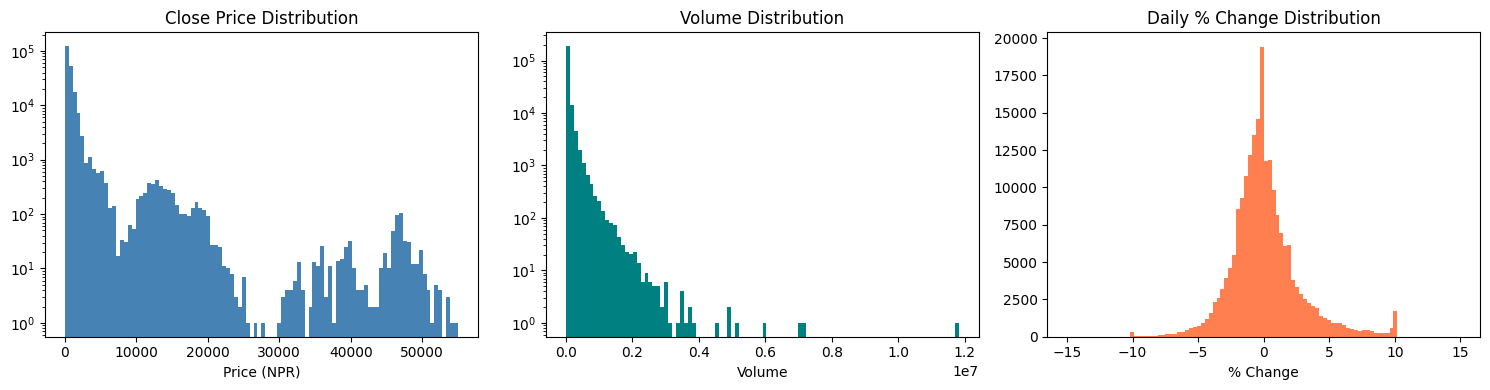

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['close'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Close Price Distribution')
axes[0].set_xlabel('Price (NPR)')
axes[0].set_yscale('log')

axes[1].hist(df['volume'], bins=100, color='teal', edgecolor='none')
axes[1].set_title('Volume Distribution')
axes[1].set_xlabel('Volume')
axes[1].set_yscale('log')

axes[2].hist(df['pct_change'], bins=100, color='coral', edgecolor='none')
axes[2].set_title('Daily % Change Distribution')
axes[2].set_xlabel('% Change')

plt.tight_layout()
plt.show()
#plots 3 histogram of close price volume and price change

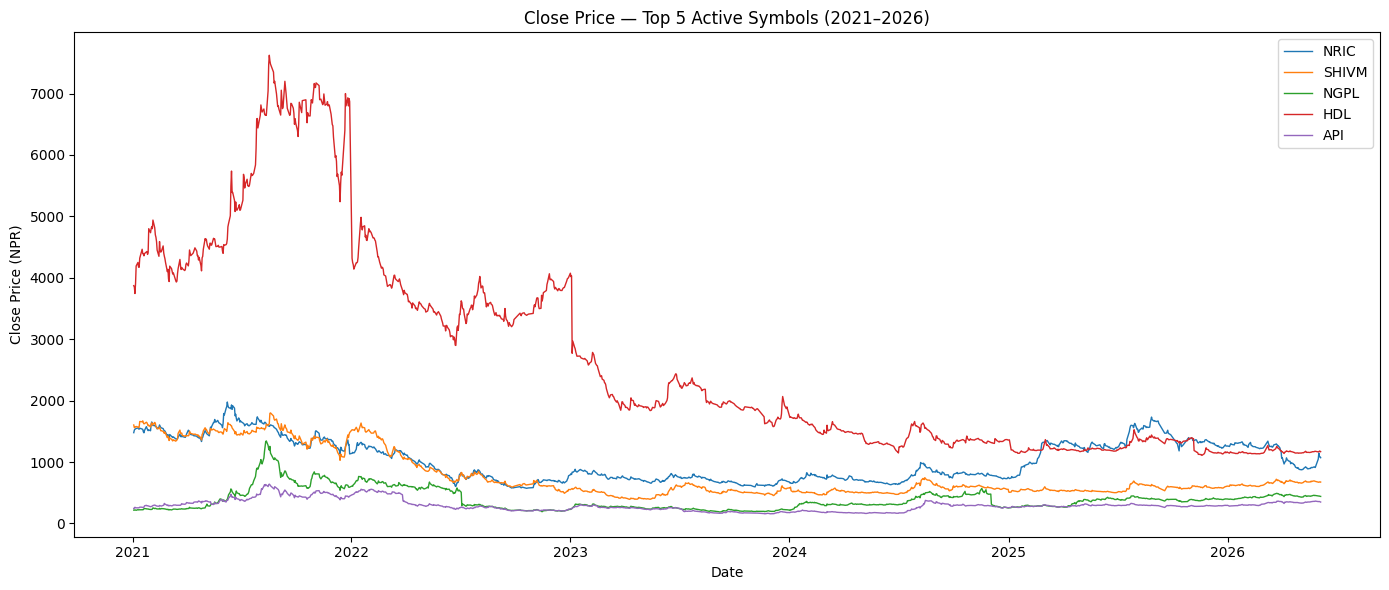

In [48]:
top5 = activity.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    sub = df[df['symbol'] == sym]
    ax.plot(sub['date'], sub['close'], label=sym, linewidth=1)

ax.set_title('Close Price — Top 5 Active Symbols (2021–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (NPR)')
ax.legend()
plt.tight_layout()
plt.show()
# checks top 5 symbols active close price comparision trend

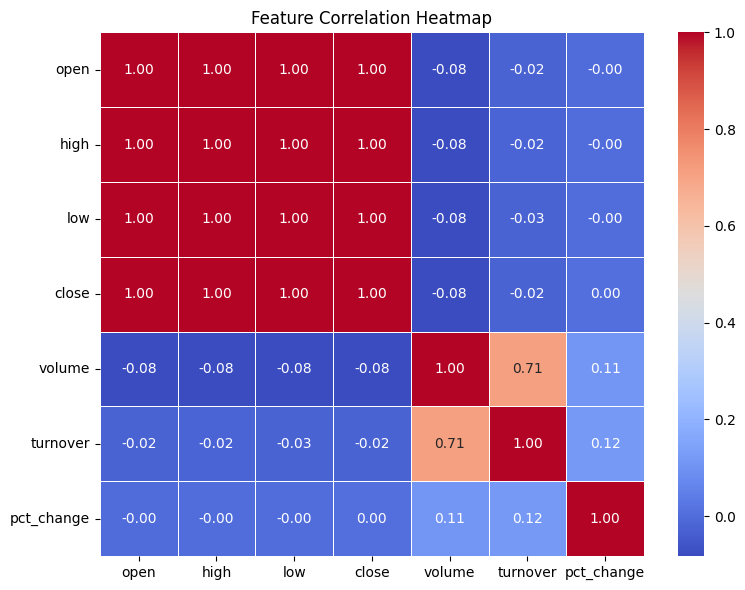

In [49]:
corr = df[['open','high','low','close','volume','turnover','pct_change']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
#correlation heat map between the features

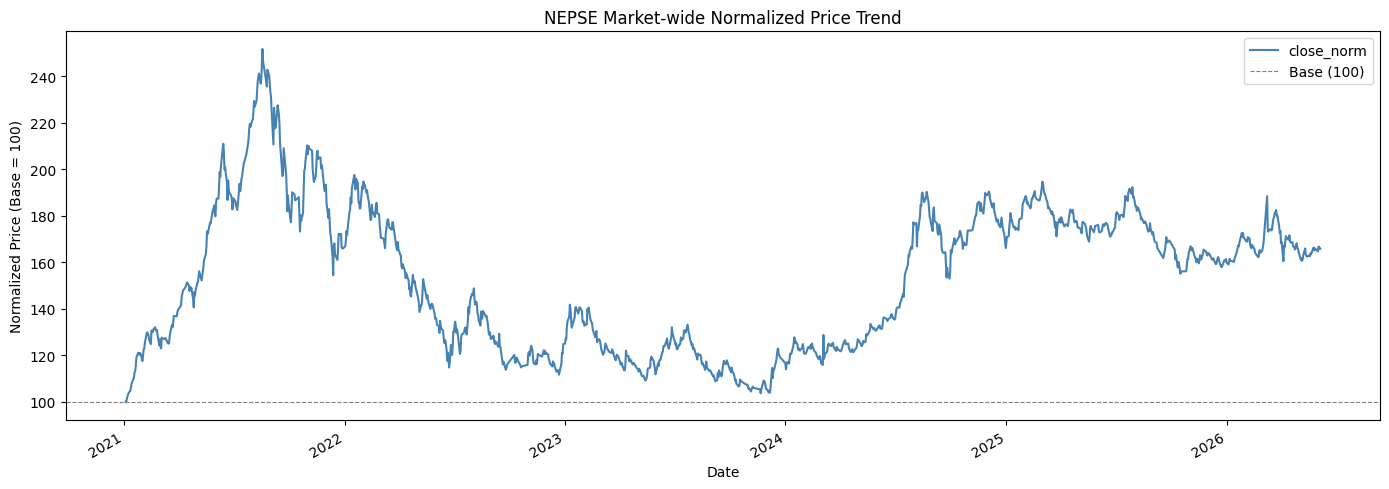

In [50]:
df['close_norm'] = df.groupby('symbol')['close'].transform(
    lambda x: x / x.iloc[0] * 100
)
market_trend = df.groupby('date')['close_norm'].mean()

plt.figure(figsize=(14, 5))
market_trend.plot(color='steelblue', linewidth=1.5)
plt.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='Base (100)')
plt.title('NEPSE Market-wide Normalized Price Trend')
plt.ylabel('Normalized Price (Base = 100)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


df = df.drop(columns=['close_norm'])
#knowing the price trend normalizing the price of individual symbol too 100 and knowing its trend

In [52]:
print("Min pct_change:", df['pct_change'].min())
print("Max pct_change:", df['pct_change'].max())
print("Rows with |pct_change| > 10:", (df['pct_change'].abs() > 10).sum())
print("Split-flagged rows:", df['split_flag'].sum())

extreme = df[df['pct_change'].abs() > 10]
print(extreme[['symbol','date','close','pct_change','split_flag']].head(10))
# checking extremly moved rows ans split flag overlap or not

Min pct_change: -14.99
Max pct_change: 15.0
Rows with |pct_change| > 10: 25
Split-flagged rows: 381
      symbol       date    close  pct_change  split_flag
19833   CFCL 2026-06-02   607.00       13.67           0
26597   CMF2 2023-07-20     9.35      -10.01           0
28447  CORBL 2026-04-21  2123.00       14.82           0
28450  CORBL 2026-04-24  2407.00       12.62           0
28451  CORBL 2026-04-27  2768.00       15.00           0
28452  CORBL 2026-04-28  2353.00      -14.99           0
28453  CORBL 2026-04-29  2678.00       13.81           0
28454  CORBL 2026-04-30  2400.00      -10.38           0
28455  CORBL 2026-05-04  2098.00      -12.58           0
28466  CORBL 2026-05-19  2300.00       14.26           0


In [53]:

extreme = df[df['pct_change'].abs() > 10]
print(extreme[['symbol','date','open','high','low','close','pct_change','split_flag']])

for sym in extreme['symbol'].unique():
    sub = df[df['symbol'] == sym].copy()
    idx = sub[sub['pct_change'].abs() > 10].index
    for i in idx:
        print(f"\n--- {sym} around index {i} ---")
        print(sub.loc[max(0,i-3):i+3, ['date','open','high','low','close','pct_change','split_flag']])
# checks for extreme moved symbols individually and knows which day it was extremly moved and checks its corresponding rows

       symbol       date     open     high      low    close  pct_change  \
19833    CFCL 2026-06-02   560.70   610.00   540.00   607.00       13.67   
26597    CMF2 2023-07-20    10.19    10.19     9.35     9.35      -10.01   
28447   CORBL 2026-04-21  1850.00  2123.00  1793.60  2123.00       14.82   
28450   CORBL 2026-04-24  2100.00  2457.70  1985.00  2407.00       12.62   
28451   CORBL 2026-04-27  2286.70  2768.00  2107.80  2768.00       15.00   
28452   CORBL 2026-04-28  2629.60  3183.00  2352.80  2353.00      -14.99   
28453   CORBL 2026-04-29  2470.60  2678.00  2117.60  2678.00       13.81   
28454   CORBL 2026-04-30  2544.10  2544.10  2276.30  2400.00      -10.38   
28455   CORBL 2026-05-04  2300.00  2300.00  2040.00  2098.00      -12.58   
28466   CORBL 2026-05-19  2070.00  2300.00  1955.00  2300.00       14.26   
28467   CORBL 2026-05-20  2185.00  2497.00  1994.40  1995.00      -13.26   
36032   FMDBL 2026-05-11   810.00   925.00   804.00   919.00       14.19   
36033   FMDB

In [56]:
# Combine all criteria into one selection table
selection = df.groupby('symbol').agg(
    days=('date', 'count'),
    avg_turnover=('turnover', 'mean'),
    avg_close=('close', 'mean'),
    volatility=('pct_change', 'std')
).reset_index()

# Keep only symbols with more than 1250 days
selection = selection[selection['days'] >= 1250].sort_values('avg_turnover', ascending=False)

print("Symbols with more than 1250 days:", len(selection))
print(selection.head(20)[['symbol','days','avg_turnover','avg_close','volatility']].to_string())

Symbols with more than 1250 days: 120
    symbol  days  avg_turnover    avg_close  volatility
107   NRIC  1262  1.103642e+08  1033.694873    2.422443
142  SHIVM  1262  1.011336e+08   789.917662    2.387218
89    NGPL  1262  9.463943e+07   388.566490    3.092438
44     HDL  1262  8.626460e+07  2702.963019    2.129395
7      API  1262  8.536645e+07   294.041157    2.688452
108    NRN  1262  8.530053e+07   875.082575    3.017488
2     AHPC  1262  7.851644e+07   313.482163    2.935143
121  RADHI  1260  7.331051e+07   492.378103    2.906985
84   NABIL  1262  6.556045e+07   762.220927    1.450671
91    NHPC  1262  6.546516e+07   231.636157    3.135256
144   SHPC  1262  6.531967e+07   422.925792    2.379549
4     AKPL  1262  6.508635e+07   329.378502    2.774787
93    NICA  1262  6.419060e+07   607.998233    1.784731
45   HIDCL  1262  6.373635e+07   261.919501    2.715022
169  UPPER  1262  6.331329e+07   379.021339    2.581223
101   NLIC  1262  6.144971e+07   995.295983    1.886457
168   UPCL

In [59]:
selected_symbols = ['NABIL', 'NICA', 'NLIC', 'NRIC', 'SHIVM', 'HDL', 'NTC', 'AHPC', 'UPPER', 'NGPL']

df_selected = df[df['symbol'].isin(selected_symbols)].reset_index(drop=True)

print("Shape:", df_selected.shape)
print("Symbols found:", df_selected['symbol'].nunique())
print(df_selected.groupby('symbol').size())
# choosed symbols of differrent sector

Shape: (12620, 10)
Symbols found: 10
symbol
AHPC     1262
HDL      1262
NABIL    1262
NGPL     1262
NICA     1262
NLIC     1262
NRIC     1262
NTC      1262
SHIVM    1262
UPPER    1262
dtype: int64


## Feature engineering

In [62]:
df_selected['log_return'] = df_selected.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)

df_selected['daily_range'] = df_selected['high'] - df_selected['low']

df_selected['prev_close'] = df_selected.groupby('symbol')['close'].shift(1)
df_selected['gap'] = df_selected['open'] - df_selected['prev_close']
df_selected = df_selected.drop(columns=['prev_close'])

print(df_selected[['symbol','date','close','log_return','daily_range','gap']].head(15))
# three features log_return , daily_range and gap betwwen close of consecutive days.

   symbol       date  close  log_return  daily_range   gap
0    AHPC 2021-01-03  208.0         NaN         13.0   NaN
1    AHPC 2021-01-04  210.0    0.009569         15.0   4.0
2    AHPC 2021-01-05  226.0    0.073427         19.0   4.0
3    AHPC 2021-01-06  225.0   -0.004435         14.0   4.0
4    AHPC 2021-01-07  235.0    0.043485         15.0   4.0
5    AHPC 2021-01-10  229.0   -0.025864         10.0   0.0
6    AHPC 2021-01-11  226.0   -0.013187         17.0  11.0
7    AHPC 2021-01-12  229.0    0.013187          6.0   3.0
8    AHPC 2021-01-13  234.0    0.021599         16.0  11.0
9    AHPC 2021-01-17  235.0    0.004264         12.0   0.0
10   AHPC 2021-01-18  231.0   -0.017168         10.0   1.0
11   AHPC 2021-01-19  233.0    0.008621         10.0   2.0
12   AHPC 2021-01-20  235.0    0.008547          7.0   0.0
13   AHPC 2021-01-21  243.0    0.033476         10.0   2.0
14   AHPC 2021-01-24  253.0    0.040328         18.0   7.0


In [61]:
print(df_selected[df_selected['symbol']=='AHPC'][['date','open','close','gap']].head(10))

        date   open  close   gap
0 2021-01-03  217.0  208.0   NaN
1 2021-01-04  212.0  210.0   4.0
2 2021-01-05  214.0  226.0   4.0
3 2021-01-06  230.0  225.0   4.0
4 2021-01-07  229.0  235.0   4.0
5 2021-01-10  235.0  229.0   0.0
6 2021-01-11  240.0  226.0  11.0
7 2021-01-12  229.0  229.0   3.0
8 2021-01-13  240.0  234.0  11.0
9 2021-01-17  234.0  235.0   0.0


In [63]:
for window in [5, 10, 20, 50]:
    df_selected[f'sma_{window}'] = df_selected.groupby('symbol')['close'].transform(
        lambda x: x.rolling(window=window).mean()
    )
    df_selected[f'ema_{window}'] = df_selected.groupby('symbol')['close'].transform(
        lambda x: x.ewm(span=window, adjust=False).mean()
    )

print(df_selected[['symbol','date','close','sma_5','sma_20','ema_5','ema_20']].head(20))
# calaculate moving averages with 5, 10, 20, 50 days averages

   symbol       date  close  sma_5  sma_20       ema_5      ema_20
0    AHPC 2021-01-03  208.0    NaN     NaN  208.000000  208.000000
1    AHPC 2021-01-04  210.0    NaN     NaN  208.666667  208.190476
2    AHPC 2021-01-05  226.0    NaN     NaN  214.444444  209.886621
3    AHPC 2021-01-06  225.0    NaN     NaN  217.962963  211.325991
4    AHPC 2021-01-07  235.0  220.8     NaN  223.641975  213.580658
5    AHPC 2021-01-10  229.0  225.0     NaN  225.427984  215.049167
6    AHPC 2021-01-11  226.0  228.2     NaN  225.618656  216.092103
7    AHPC 2021-01-12  229.0  228.8     NaN  226.745770  217.321427
8    AHPC 2021-01-13  234.0  230.6     NaN  229.163847  218.909862
9    AHPC 2021-01-17  235.0  230.6     NaN  231.109231  220.442257
10   AHPC 2021-01-18  231.0  231.0     NaN  231.072821  221.447756
11   AHPC 2021-01-19  233.0  232.4     NaN  231.715214  222.547970
12   AHPC 2021-01-20  235.0  233.6     NaN  232.810143  223.733877
13   AHPC 2021-01-21  243.0  235.4     NaN  236.206762  225.56

In [64]:
df_selected['volatility_10'] = df_selected.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(window=10).std()
)
df_selected['volatility_20'] = df_selected.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(window=20).std()
)

print(df_selected[['symbol','date','log_return','volatility_10','volatility_20']].head(25))
# it gives stock is stable or volatile in 10 , 20 days period

   symbol       date  log_return  volatility_10  volatility_20
0    AHPC 2021-01-03         NaN            NaN            NaN
1    AHPC 2021-01-04    0.009569            NaN            NaN
2    AHPC 2021-01-05    0.073427            NaN            NaN
3    AHPC 2021-01-06   -0.004435            NaN            NaN
4    AHPC 2021-01-07    0.043485            NaN            NaN
5    AHPC 2021-01-10   -0.025864            NaN            NaN
6    AHPC 2021-01-11   -0.013187            NaN            NaN
7    AHPC 2021-01-12    0.013187            NaN            NaN
8    AHPC 2021-01-13    0.021599            NaN            NaN
9    AHPC 2021-01-17    0.004264            NaN            NaN
10   AHPC 2021-01-18   -0.017168       0.029981            NaN
11   AHPC 2021-01-19    0.008621       0.029986            NaN
12   AHPC 2021-01-20    0.008547       0.020280            NaN
13   AHPC 2021-01-21    0.033476       0.022017            NaN
14   AHPC 2021-01-24    0.040328       0.021463        

In [65]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_selected['rsi_14'] = df_selected.groupby('symbol')['close'].transform(
    lambda x: compute_rsi(x, 14)
)

print(df_selected[['symbol','date','close','rsi_14']].head(25))
print("\nRSI stats:\n", df_selected['rsi_14'].describe())
# relative strength index which gives the stock has been overbought or oversold in past 14 days

   symbol       date  close     rsi_14
0    AHPC 2021-01-03  208.0        NaN
1    AHPC 2021-01-04  210.0        NaN
2    AHPC 2021-01-05  226.0        NaN
3    AHPC 2021-01-06  225.0        NaN
4    AHPC 2021-01-07  235.0        NaN
5    AHPC 2021-01-10  229.0        NaN
6    AHPC 2021-01-11  226.0        NaN
7    AHPC 2021-01-12  229.0        NaN
8    AHPC 2021-01-13  234.0        NaN
9    AHPC 2021-01-17  235.0        NaN
10   AHPC 2021-01-18  231.0        NaN
11   AHPC 2021-01-19  233.0        NaN
12   AHPC 2021-01-20  235.0        NaN
13   AHPC 2021-01-21  243.0  77.777778
14   AHPC 2021-01-24  253.0  80.821918
15   AHPC 2021-01-25  252.0  79.166667
16   AHPC 2021-01-26  249.0  69.491525
17   AHPC 2021-01-27  248.0  69.491525
18   AHPC 2021-01-28  246.0  60.784314
19   AHPC 2021-01-31  242.0  63.265306
20   AHPC 2021-02-01  242.0  67.391304
21   AHPC 2021-02-02  242.0  65.116279
22   AHPC 2021-02-03  253.0  69.387755
23   AHPC 2021-02-04  270.0  76.923077
24   AHPC 2021-02-07  284

In [66]:
def compute_macd(series):
    ema_12 = series.ewm(span=12, adjust=False).mean()
    ema_26 = series.ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    histogram = macd - signal
    return macd, signal, histogram

df_selected[['macd','macd_signal','macd_hist']] = df_selected.groupby('symbol')['close'].transform(
    lambda x: compute_macd(x)[0]
).to_frame().join(
    df_selected.groupby('symbol')['close'].transform(lambda x: compute_macd(x)[1]).rename('macd_signal')
).join(
    df_selected.groupby('symbol')['close'].transform(lambda x: compute_macd(x)[2]).rename('macd_hist')
)

print(df_selected[['symbol','date','close','macd','macd_signal','macd_hist']].head(30))

   symbol       date  close       macd  macd_signal  macd_hist
0    AHPC 2021-01-03  208.0   0.000000     0.000000   0.000000
1    AHPC 2021-01-04  210.0   0.159544     0.031909   0.127635
2    AHPC 2021-01-05  226.0   1.559078     0.337343   1.221736
3    AHPC 2021-01-06  225.0   2.558040     0.781482   1.776558
4    AHPC 2021-01-07  235.0   4.109272     1.447040   2.662232
5    AHPC 2021-01-10  229.0   4.799162     2.117465   2.681698
6    AHPC 2021-01-11  226.0   5.045667     2.703105   2.342562
7    AHPC 2021-01-12  229.0   5.420614     3.246607   2.174007
8    AHPC 2021-01-13  234.0   6.051462     3.807578   2.243884
9    AHPC 2021-01-17  235.0   6.556527     4.357368   2.199159
10   AHPC 2021-01-18  231.0   6.558425     4.797579   1.760846
11   AHPC 2021-01-19  233.0   6.644717     5.167007   1.477711
12   AHPC 2021-01-20  235.0   6.796146     5.492835   1.303311
13   AHPC 2021-01-21  243.0   7.475514     5.889371   1.586144
14   AHPC 2021-01-24  253.0   8.720313     6.455559   2

In [67]:
def add_macd(group):
    ema_12 = group['close'].ewm(span=12, adjust=False).mean()
    ema_26 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = ema_12 - ema_26
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    return group

df_selected = df_selected.groupby('symbol', group_keys=False).apply(add_macd)

print(df_selected[['symbol','date','close','macd','macd_signal','macd_hist']].head(30))


   symbol       date  close       macd  macd_signal  macd_hist
0    AHPC 2021-01-03  208.0   0.000000     0.000000   0.000000
1    AHPC 2021-01-04  210.0   0.159544     0.031909   0.127635
2    AHPC 2021-01-05  226.0   1.559078     0.337343   1.221736
3    AHPC 2021-01-06  225.0   2.558040     0.781482   1.776558
4    AHPC 2021-01-07  235.0   4.109272     1.447040   2.662232
5    AHPC 2021-01-10  229.0   4.799162     2.117465   2.681698
6    AHPC 2021-01-11  226.0   5.045667     2.703105   2.342562
7    AHPC 2021-01-12  229.0   5.420614     3.246607   2.174007
8    AHPC 2021-01-13  234.0   6.051462     3.807578   2.243884
9    AHPC 2021-01-17  235.0   6.556527     4.357368   2.199159
10   AHPC 2021-01-18  231.0   6.558425     4.797579   1.760846
11   AHPC 2021-01-19  233.0   6.644717     5.167007   1.477711
12   AHPC 2021-01-20  235.0   6.796146     5.492835   1.303311
13   AHPC 2021-01-21  243.0   7.475514     5.889371   1.586144
14   AHPC 2021-01-24  253.0   8.720313     6.455559   2

/tmp/ipykernel_1805/3058039760.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_selected = df_selected.groupby('symbol', group_keys=False).apply(add_macd)


In [75]:
def add_bollinger(group, window=20):
    group['bb_mid'] = group['close'].rolling(window=window).mean()
    group['bb_std'] = group['close'].rolling(window=window).std()
    group['bb_upper'] = group['bb_mid'] + 2 * group['bb_std']
    group['bb_lower'] = group['bb_mid'] - 2 * group['bb_std']
    group['bb_width'] = (group['bb_upper'] - group['bb_lower']) / group['bb_mid']
    group['bb_position'] = (group['close'] - group['bb_lower']) / (group['bb_upper'] - group['bb_lower'])
    return group

df_selected = df_selected.groupby('symbol', group_keys=False).apply(add_bollinger)

print(df_selected[['symbol','date','close','bb_upper','bb_lower','bb_width','bb_position']].head(25))

   symbol       date  close    bb_upper    bb_lower  bb_width  bb_position
0    AHPC 2021-01-03  208.0         NaN         NaN       NaN          NaN
1    AHPC 2021-01-04  210.0         NaN         NaN       NaN          NaN
2    AHPC 2021-01-05  226.0         NaN         NaN       NaN          NaN
3    AHPC 2021-01-06  225.0         NaN         NaN       NaN          NaN
4    AHPC 2021-01-07  235.0         NaN         NaN       NaN          NaN
5    AHPC 2021-01-10  229.0         NaN         NaN       NaN          NaN
6    AHPC 2021-01-11  226.0         NaN         NaN       NaN          NaN
7    AHPC 2021-01-12  229.0         NaN         NaN       NaN          NaN
8    AHPC 2021-01-13  234.0         NaN         NaN       NaN          NaN
9    AHPC 2021-01-17  235.0         NaN         NaN       NaN          NaN
10   AHPC 2021-01-18  231.0         NaN         NaN       NaN          NaN
11   AHPC 2021-01-19  233.0         NaN         NaN       NaN          NaN
12   AHPC 2021-01-20  235

/tmp/ipykernel_1805/3668506173.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_selected = df_selected.groupby('symbol', group_keys=False).apply(add_bollinger)


In [76]:
def add_volume_features(group):
    group['volume_sma_10'] = group['volume'].rolling(window=10).mean()
    group['volume_ratio'] = group['volume'] / group['volume_sma_10']
    group['turnover_sma_10'] = group['turnover'].rolling(window=10).mean()
    return group

df_selected = df_selected.groupby('symbol', group_keys=False).apply(add_volume_features)

print(df_selected[['symbol','date','volume','volume_sma_10','volume_ratio']].head(25))

   symbol       date    volume  volume_sma_10  volume_ratio
0    AHPC 2021-01-03   27868.0            NaN           NaN
1    AHPC 2021-01-04   42967.0            NaN           NaN
2    AHPC 2021-01-05  109556.0            NaN           NaN
3    AHPC 2021-01-06   53792.0            NaN           NaN
4    AHPC 2021-01-07  125781.0            NaN           NaN
5    AHPC 2021-01-10  162701.0            NaN           NaN
6    AHPC 2021-01-11   42779.0            NaN           NaN
7    AHPC 2021-01-12   25298.0            NaN           NaN
8    AHPC 2021-01-13   78904.0            NaN           NaN
9    AHPC 2021-01-17  104401.0        77404.7      1.348768
10   AHPC 2021-01-18  100417.0        84659.6      1.186127
11   AHPC 2021-01-19   73670.0        87729.9      0.839737
12   AHPC 2021-01-20   64457.0        83220.0      0.774537
13   AHPC 2021-01-21  195229.0        97363.7      2.005152
14   AHPC 2021-01-24  140347.0        98820.3      1.420224
15   AHPC 2021-01-25  192340.0       101

/tmp/ipykernel_1805/1397668275.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_selected = df_selected.groupby('symbol', group_keys=False).apply(add_volume_features)


In [77]:
print("Inf in volume_ratio:", np.isinf(df_selected['volume_ratio']).sum())

Inf in volume_ratio: 0


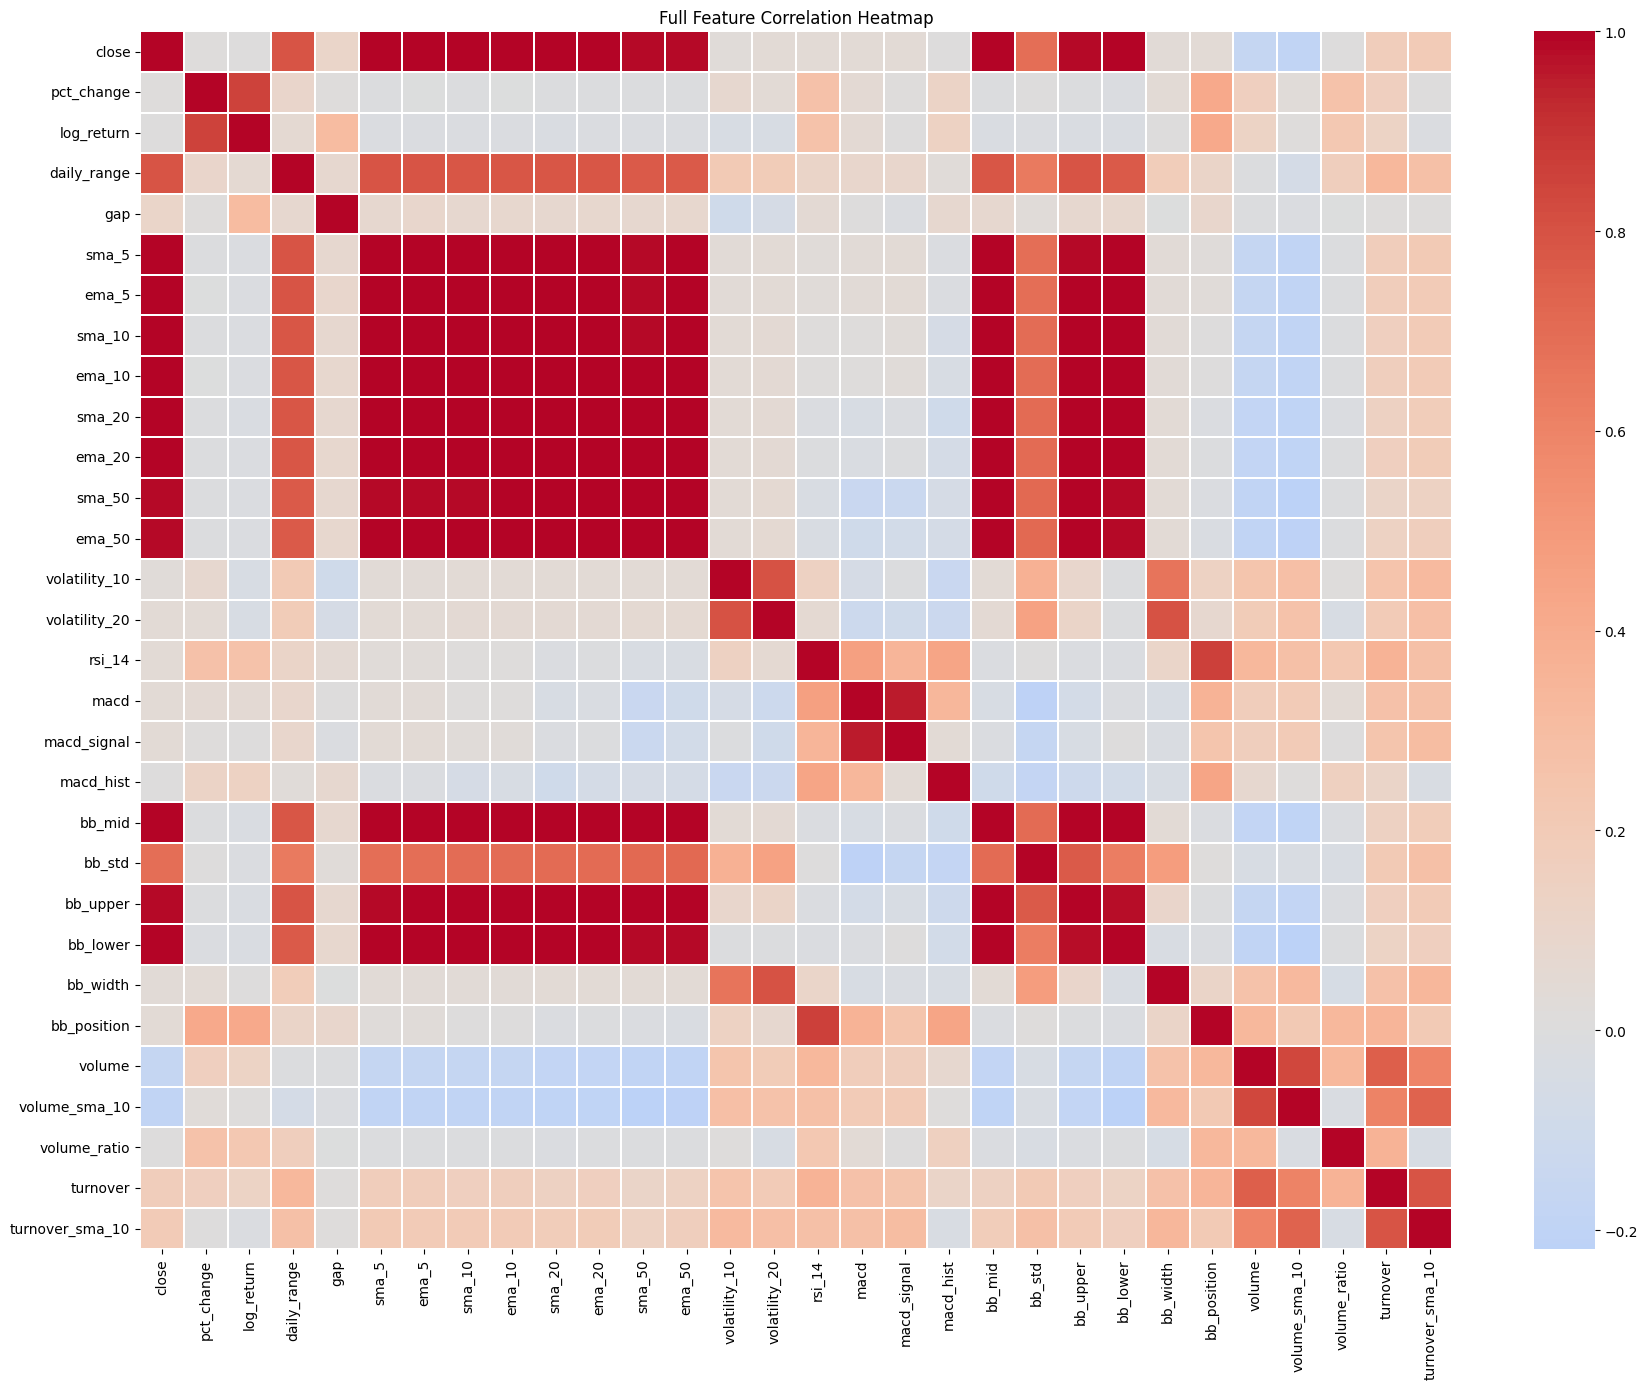

Feature pairs with |correlation| > 0.9:

feature_1   feature_2  correlation
   sma_20      bb_mid     1.000000
    sma_5       ema_5     0.999907
   sma_10      ema_10     0.999790
   ema_20      bb_mid     0.999731
   sma_20      ema_20     0.999731
    ema_5      ema_10     0.999594
    sma_5      ema_10     0.999505
   sma_50      ema_50     0.999373
   ema_10      ema_20     0.999267
    close       ema_5     0.999153
   sma_10      ema_20     0.999118
    ema_5      sma_10     0.999059
    sma_5      sma_10     0.999034
    close       sma_5     0.998705
   ema_10      sma_20     0.998593
   ema_10      bb_mid     0.998593
   sma_10      bb_mid     0.998499
   sma_10      sma_20     0.998499
    close      ema_10     0.997964
    ema_5      ema_20     0.997950
    sma_5      ema_20     0.997760
   ema_20      ema_50     0.997008
    close      sma_10     0.996875
    ema_5      sma_20     0.996865
    ema_5      bb_mid     0.996865
   ema_50      bb_mid     0.996653
   sma_20     

In [78]:
# All engineered features (excluding identifiers and raw OHLC)
feature_cols = ['close', 'pct_change', 'log_return', 'daily_range', 'gap',
                 'sma_5', 'ema_5', 'sma_10', 'ema_10', 'sma_20', 'ema_20', 'sma_50', 'ema_50',
                 'volatility_10', 'volatility_20', 'rsi_14', 'macd', 'macd_signal', 'macd_hist',
                 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width', 'bb_position',
                 'volume', 'volume_sma_10', 'volume_ratio', 'turnover', 'turnover_sma_10']

corr = df_selected[feature_cols].corr()

# --- Heatmap ---
plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Full Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- Proof: extract highly correlated pairs (evidence for dropping) ---
threshold = 0.90

# Get upper triangle only (avoid duplicate pairs and self-correlation)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('correlation', key=abs, ascending=False)

print(f"Feature pairs with |correlation| > {threshold}:\n")
print(high_corr_pairs.to_string(index=False))